### 주제: 건설 장비 내부 기계 부품의 마모 상태 및 윤활 성능을 오일 데이터 분석을 통해 확인하고, AI를 활용한 분류 모델 개발을 통해 적절한 교체 주기를 파악

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import pickle

from sklearn.preprocessing import StandardScaler
from scipy.stats import kurtosis, skew, ttest_ind, mannwhitneyu
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


데이터 분석 목표: 샘플 오일 관련 부품 정보를 분석해 오일 정상 여부 예측

In [61]:
train = pd.read_csv('D:/김동영/11_Github/mygit-1/데이터사이언스수업/과제/최종과제/HD현대해커톤/train.csv')
test_df = pd.read_csv('D:/김동영/11_Github/mygit-1/데이터사이언스수업/과제/최종과제/HD현대해커톤/test.csv')
submission = pd.read_csv('D:/김동영/11_Github/mygit-1/데이터사이언스수업/과제/최종과제/HD현대해커톤/sample_submission.csv')

In [62]:
test_df.columns

Index(['ID', 'COMPONENT_ARBITRARY', 'ANONYMOUS_1', 'YEAR', 'ANONYMOUS_2', 'AG',
       'CO', 'CR', 'CU', 'FE', 'H2O', 'MN', 'MO', 'NI', 'PQINDEX', 'TI', 'V',
       'V40', 'ZN'],
      dtype='object')

In [63]:
columns = ['ID', 'COMPONENT_ARBITRARY', 'ANONYMOUS_1', 'YEAR', 'ANONYMOUS_2', 'AG',
       'CO', 'CR', 'CU', 'FE', 'H2O', 'MN', 'MO', 'NI', 'PQINDEX', 'TI', 'V',
       'V40', 'ZN','Y_LABEL']

변수 정보   
ANONYMOUS_1 - 무명 Feature 1. 수치형 데이터   
ANONYMOUS_2 - 무명 Feature 2. 수치형 데이터   
AG, CO, CR, FE, H2O, MN, MO, NI, TI, V, ZN - 원소기호   
V40 - 40도에서 측정한 액체의 점도   
YEAR - 오일샘플 및 진단 해(Year)    
PQINDEX(Particle Quantifier Index) : Particle Quantifier Index(PQ Index), 또는 PQI라고도 불리는 이 지표는 입자의 크기와 상관없이 윤활유 샘플 내에 존재하는 전체 강자성 물질(자성을 띤 금속 입자)의 양을 측정하는 방법이다.
이 지표는 마모로 인한 문제가 발생할 가능성을 조기에 감지하기 위한 선별 검사 도구로 사용되며, 예지 보전(predictive maintenance) 프로그램에서 자주 활용된다.    

Y_LABEL - 타깃변수로 0일 때 정상, 1일 때 비정상


train 데이터에는 존재하나 test 데이터에는 없는 변수들 존재했었다. 이는 모델 학습 시 사용할 수 없는 변수들이기 때문에 제거해주었다.    

In [64]:
train_df = train[columns]

In [65]:
train_df['COMPONENT_ARBITRARY'].value_counts()

COMPONENT_ARBITRARY
COMPONENT3    7050
COMPONENT1    3890
COMPONENT2    2316
COMPONENT4     839
Name: count, dtype: int64

부품 종류로는 4개가 있으며 1은 3890개, 2는 2316개, 3은 7050개, 4는 839개씩 있다.    

In [66]:
# COMPONENT_ARBITRARY별 Y_LABEL의 0,1 개수
count = train_df.groupby('COMPONENT_ARBITRARY')['Y_LABEL'].value_counts().unstack().fillna(0)
print("개수:\n", count)

# COMPONENT_ARBITRARY별 Y_LABEL의 0,1 비율
ratio = train_df.groupby('COMPONENT_ARBITRARY')['Y_LABEL'].value_counts(normalize=True).unstack().fillna(0)
print("\n비율:\n", ratio)


개수:
 Y_LABEL                 0     1
COMPONENT_ARBITRARY            
COMPONENT1           3500   390
COMPONENT2           1915   401
COMPONENT3           4906  2144
COMPONENT4            750    89

비율:
 Y_LABEL                     0         1
COMPONENT_ARBITRARY                    
COMPONENT1           0.899743  0.100257
COMPONENT2           0.826857  0.173143
COMPONENT3           0.695887  0.304113
COMPONENT4           0.893921  0.106079


COMPONENT_ARBITRARY별로 오일 정상, 비정상 개수 및 비율을 확인해본 결과 COMPONENT 2와 3에서 이상 오일 비율이 높게 나온 것을 확인할 수 있었다.

In [67]:
train_df.groupby('COMPONENT_ARBITRARY').mean(numeric_only=True)

# 평균값을 표로 보기 좋게 출력
mean_df = train_df.groupby('COMPONENT_ARBITRARY').mean(numeric_only=True)
display(mean_df)

,ANONYMOUS_1,YEAR,ANONYMOUS_2,AG,CO,CR,CU,FE,H2O,MN,MO,NI,PQINDEX,TI,V,V40,ZN,Y_LABEL
COMPONENT_ARBITRARY,,,,,,,,,,,,,,,,,,
COMPONENT1,-0.986054,2013.729563,-0.959173,0.025193,0.014396,1.910540,9.929563,27.057069,0.002699,0.514910,69.364267,0.152185,20.422622,0.055013,0.024422,102.678103,1161.010283,0.100257
COMPONENT2,-0.986206,2013.718912,-0.961256,0.024180,0.009499,0.515976,56.677029,18.890328,0.003282,0.155872,0.652418,0.027634,27.230570,0.032815,0.010794,52.720695,505.785838,0.173143
COMPONENT3,-0.984818,2013.494043,-0.961531,0.028227,0.044397,5.361986,32.252057,332.500426,0.064525,5.137163,3.415745,1.362553,807.300567,1.372908,0.082837,136.411370,241.379574,0.304113
COMPONENT4,-0.984588,2014.443385,-0.953130,0.013111,0.007151,0.091776,107.109654,21.651967,0.001549,0.852205,50.958284,0.034565,21.091776,0.010727,0.011919,69.310012,1081.669845,0.106079


변수들간의 수치를 직접 비교하기 위해서 스케일링을 적용시켰다

In [68]:
# 스케일링 대상 수치형 변수 리스트 (ID, COMPONENT_ARBITRARY, Y_LABEL 제외)
num_cols = [col for col in train_df.columns if col not in ['ID', 'COMPONENT_ARBITRARY', 'Y_LABEL']]

scaler = StandardScaler()
train_df_scaled = train_df.copy()
train_df_scaled[num_cols] = scaler.fit_transform(train_df[num_cols])

display(train_df_scaled.head())

,ID,COMPONENT_ARBITRARY,ANONYMOUS_1,YEAR,ANONYMOUS_2,AG,CO,CR,CU,FE,H2O,MN,MO,NI,PQINDEX,TI,V,V40,ZN,Y_LABEL
0,TRAIN_00000,COMPONENT3,-0.393763,-0.669043,-0.340760,-0.150214,-0.089633,0.339245,0.336858,1.331290,-0.041588,1.186914,-0.384284,1.384414,5.293270,0.622282,-0.10655,0.899892,-0.966002,1
1,TRAIN_00001,COMPONENT2,-0.426022,1.853268,-0.022576,-0.150214,-0.089633,-0.115388,-0.027612,-0.330406,-0.041588,-0.250456,-0.400998,-0.191804,-0.259244,-0.102635,-0.10655,-1.317376,0.119147,0
2,TRAIN_00002,COMPONENT2,-0.173409,0.339881,-0.340760,-0.150214,-0.089633,-0.080416,-0.252497,-0.326655,-0.041588,-0.250456,-0.400998,-0.191804,-0.260552,-0.102635,-0.10655,-0.740886,-0.332215,0
3,TRAIN_00003,COMPONENT3,1.006399,-0.921274,-0.340760,-0.150214,-0.089633,-0.115388,-0.260252,-0.264764,-0.041588,-0.160621,-0.400998,-0.191804,-0.242884,-0.102635,-0.10655,0.482642,-1.093888,0
4,TRAIN_00004,COMPONENT3,0.191634,0.339881,-0.340760,-0.150214,-0.089633,-0.115388,-0.268007,-0.200996,-0.041588,-0.250456,-0.400998,-0.191804,-0.129674,-0.102635,-0.10655,0.478611,-0.866326,0


이상 샘플이 Component 3에서 차지하는 비율이 0.3으로 다른 Component에 비해 높게 나온 것을 확인

## Component 3

Component 3에서 이상 샘플과 정상 샘플의 수치를 비교해보았을 때 ANONYMOUS_1, ANONYMOUS_2, YEAR, AG 변수를 제외한 나머지 변수들에서 수치적으로 큰 차이를 보였다.    

In [69]:
# COMPONENT3만 추출
comp3_df = train_df_scaled[train_df_scaled['COMPONENT_ARBITRARY'] == 'COMPONENT3']

# Y_LABEL이 0과 1인 데이터 각각 추출
comp3_0 = comp3_df[comp3_df['Y_LABEL'] == 0]
comp3_1 = comp3_df[comp3_df['Y_LABEL'] == 1]

# 주요 변수별 평균 비교
mean_0 = comp3_0.mean(numeric_only=True)
mean_1 = comp3_1.mean(numeric_only=True)
diff = pd.DataFrame({'Y_LABEL=0': mean_0, 'Y_LABEL=1': mean_1})

display(diff)

# 주요 변수별 중앙값 비교
median_0 = comp3_0.median(numeric_only=True)
median_1 = comp3_1.median(numeric_only=True)
median_diff = pd.DataFrame({'Y_LABEL=0': median_0, 'Y_LABEL=1': median_1})

display(median_diff)

,Y_LABEL=0,Y_LABEL=1
ANONYMOUS_1,0.024516,0.007497
YEAR,-0.009520,-0.109641
ANONYMOUS_2,-0.014528,-0.000537
AG,-0.005568,0.058687
CO,-0.013740,0.201287
CR,-0.053165,0.358835
CU,-0.113855,0.201662
FE,-0.041531,1.046812
H2O,-0.036323,0.208588
MN,0.001490,0.690555


,Y_LABEL=0,Y_LABEL=1
ANONYMOUS_1,-0.214207,-0.213258
YEAR,0.087650,-0.164581
ANONYMOUS_2,-0.340760,-0.340760
AG,-0.150214,-0.150214
CO,-0.089633,-0.089633
CR,-0.080416,0.024499
CU,-0.236988,-0.229233
FE,-0.154109,0.376659
H2O,-0.041588,-0.041588
MN,-0.160621,0.198722


각 변수에서의 정규분포    
파란색: 정상    
빨간색: 비정상

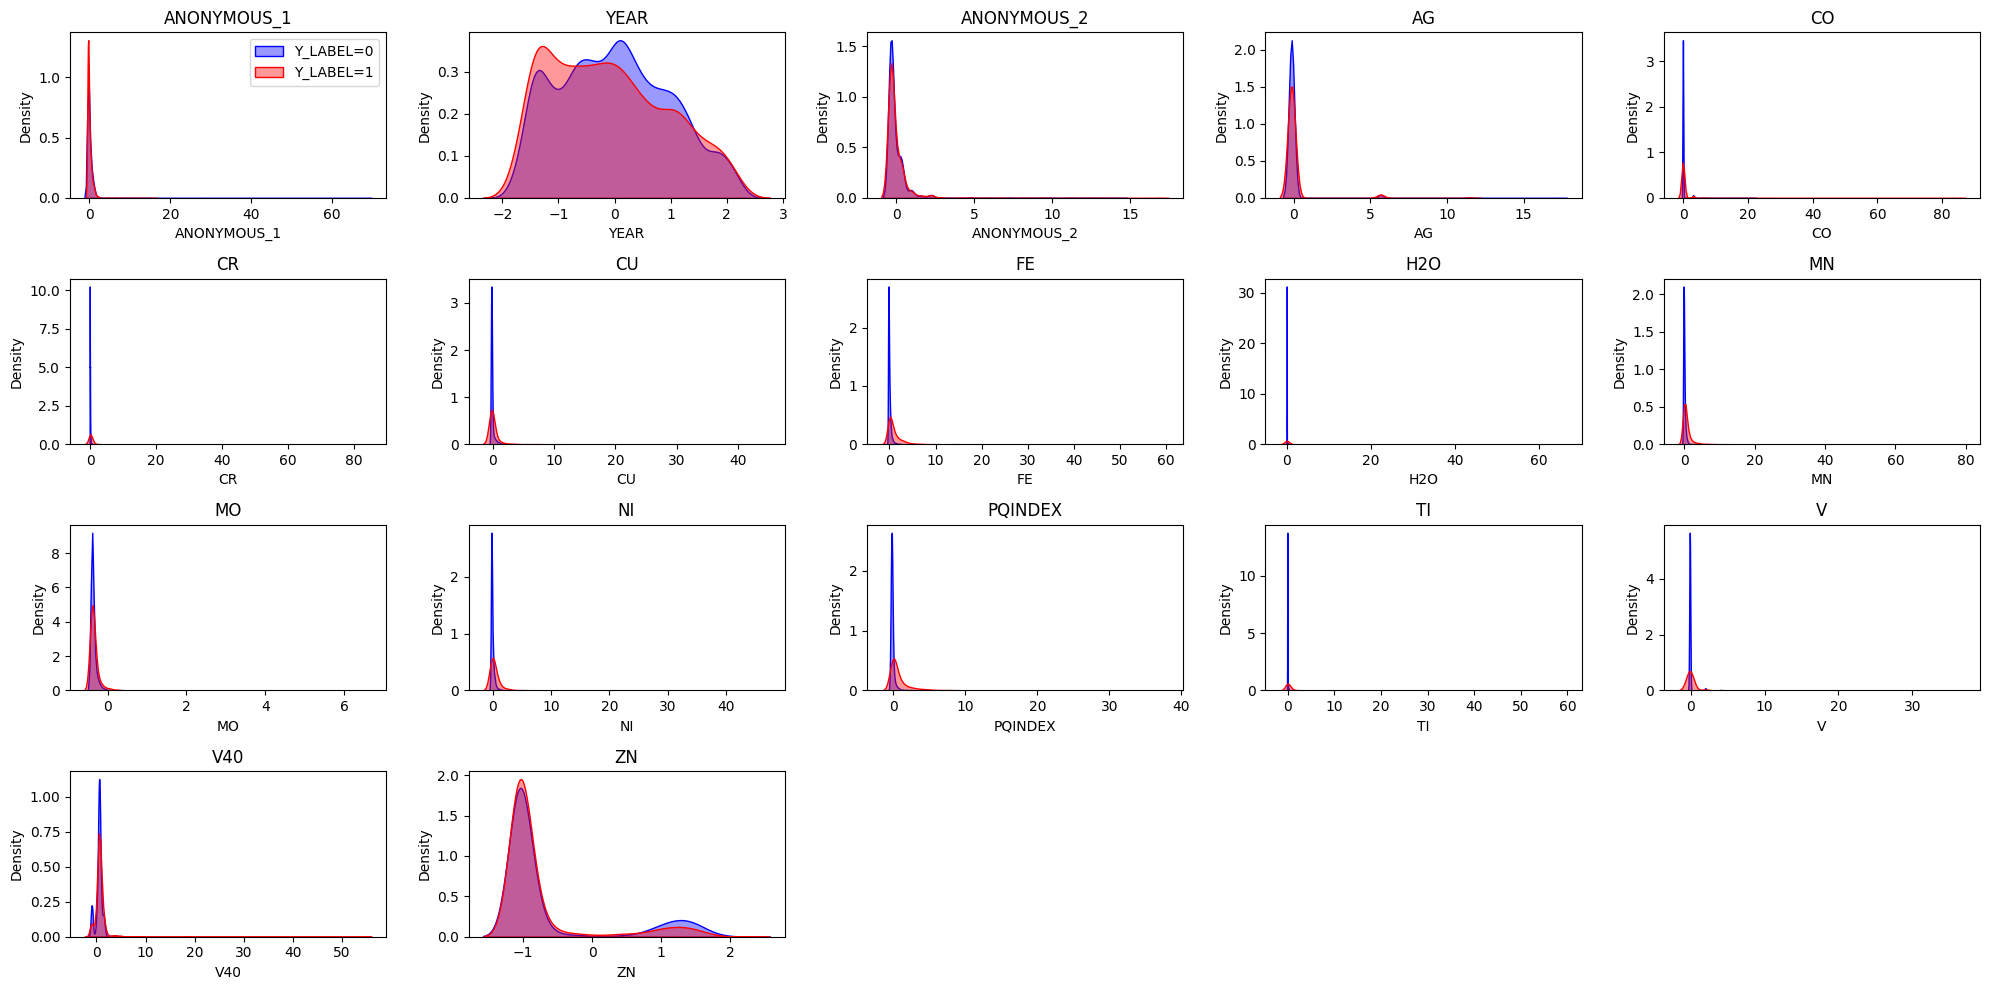

In [ ]:


plt.figure(figsize=(20, 10))
for var in num_cols:
  plt.subplot(4, 5, num_cols.index(var)+1)
  sns.kdeplot(comp3_0[var], label='Y_LABEL=0', color='blue', fill=True, alpha=0.4)
  sns.kdeplot(comp3_1[var], label='Y_LABEL=1', color='red', fill=True, alpha=0.4)
  plt.title(var)
  plt.xlabel(var)
  plt.ylabel('Density')
  if num_cols.index(var) == 0:
    plt.legend()
plt.tight_layout()
plt.show()

In [71]:
# 주요 변수별 첨도(kurtosis)와 왜도(skewness) 계산

kurt_skew = []
for col in independent_vars:
  kurt_0 = kurtosis(comp3_0[col], nan_policy='omit')
  skew_0 = skew(comp3_0[col], nan_policy='omit')
  kurt_1 = kurtosis(comp3_1[col], nan_policy='omit')
  skew_1 = skew(comp3_1[col], nan_policy='omit')
  kurt_skew.append({
    '변수': col,
    'Y_LABEL=0_첨도': kurt_0,
    'Y_LABEL=0_왜도': skew_0,
    'Y_LABEL=1_첨도': kurt_1,
    'Y_LABEL=1_왜도': skew_1
  })

kurt_skew_df = pd.DataFrame(kurt_skew)
display(kurt_skew_df)

,변수,Y_LABEL=0_첨도,Y_LABEL=0_왜도,Y_LABEL=1_첨도,Y_LABEL=1_왜도
0,ANONYMOUS_1,1512.287309,32.518268,148.893417,9.132153
1,YEAR,-0.836721,0.207422,-0.896504,0.360746
2,ANONYMOUS_2,92.750440,8.330986,102.152902,8.423066
3,AG,71.716362,7.829656,40.676281,6.111498
4,CO,415.260376,15.681666,1087.743986,29.016374
5,CR,14.239118,2.968100,620.155557,21.926679
6,CU,191.799066,10.869007,227.042089,13.423523
7,FE,23.742994,4.019570,232.819537,10.692425
8,H2O,955.484288,25.691983,416.393428,19.066077
9,MN,104.042667,8.713548,679.535894,21.096072


대부분 변수에서 분포가 비정규적이고, 이상치가 많거나 한쪽으로 치우쳐 있다. 따라서 중앙값이나, 비모수 검정 등으로 비교하는 것이 적합하다.    
특히, 비정상 집단에서 첨도와 왜도가 더 커진다.    

중앙값과 정규분포에선 FE, MN, NI, PQINDEX, CR 이 5가지 변수에서 0과 1의 차이가 도드라지는 것을 알 수 있었다.    

Boxplot으로 시각화하여 분포를 확인해보았다    

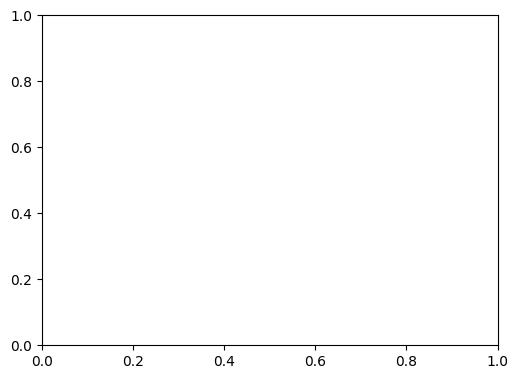

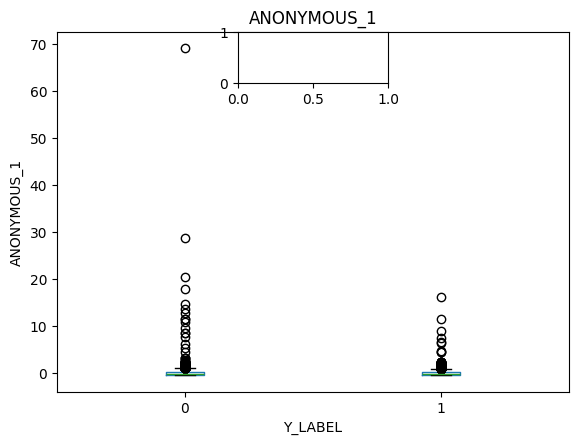

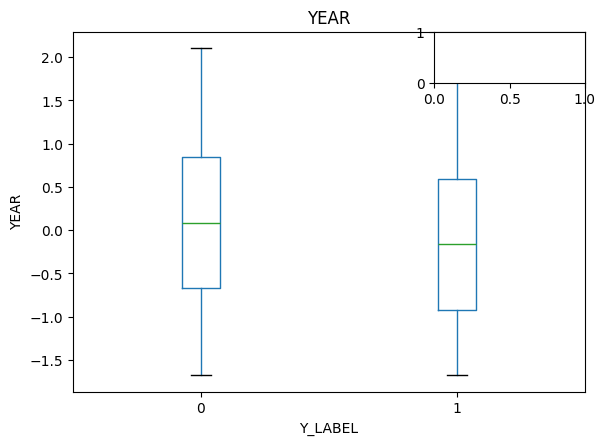

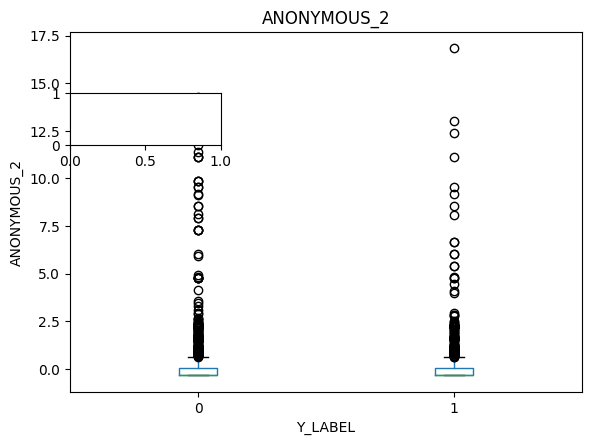

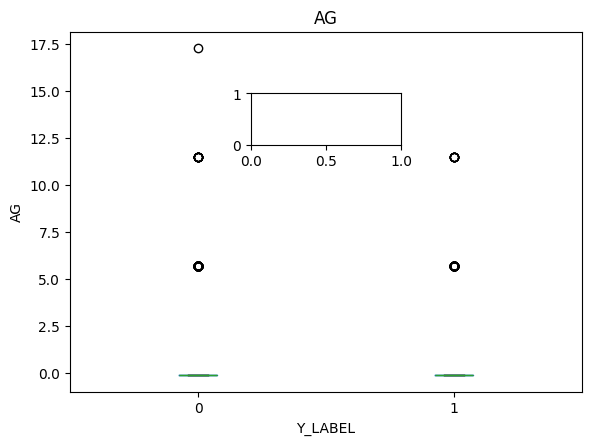

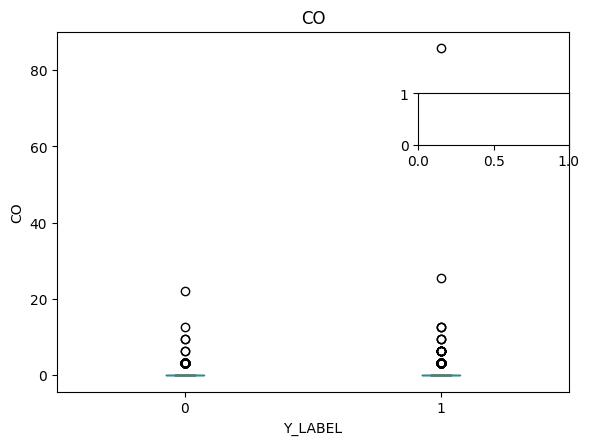

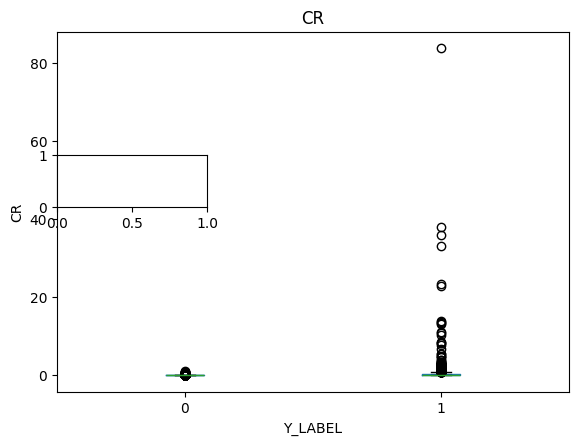

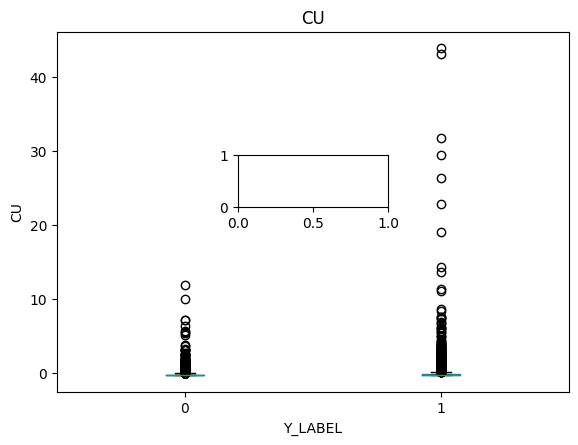

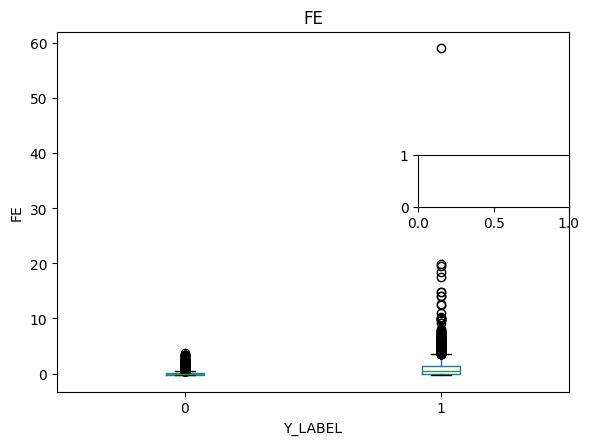

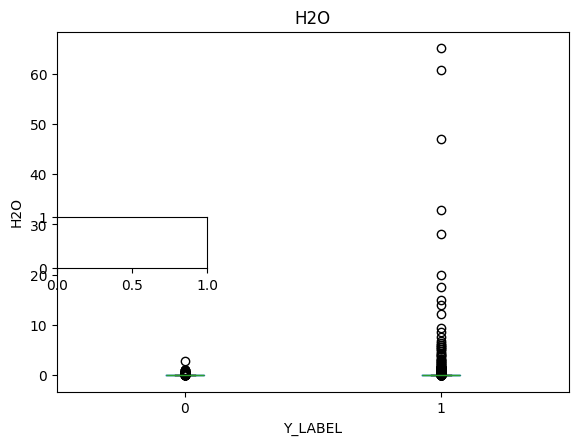

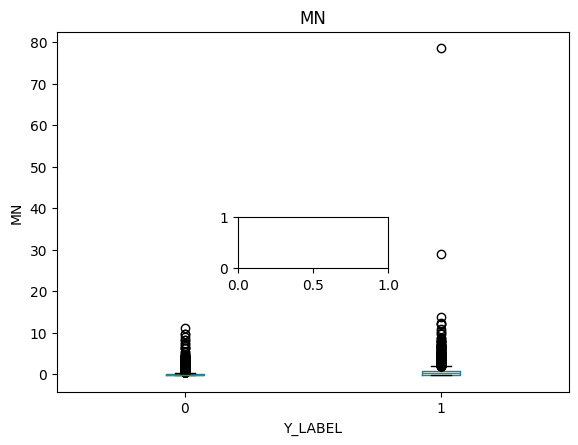

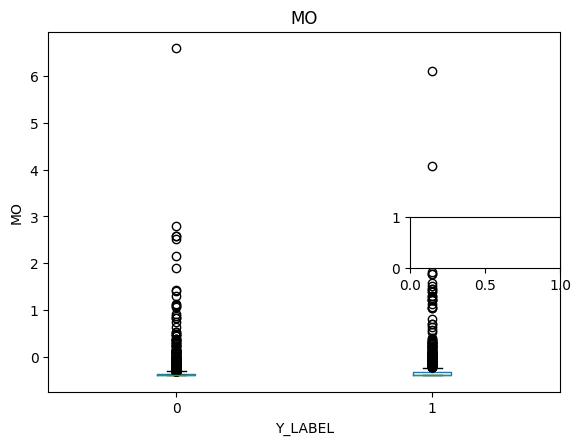

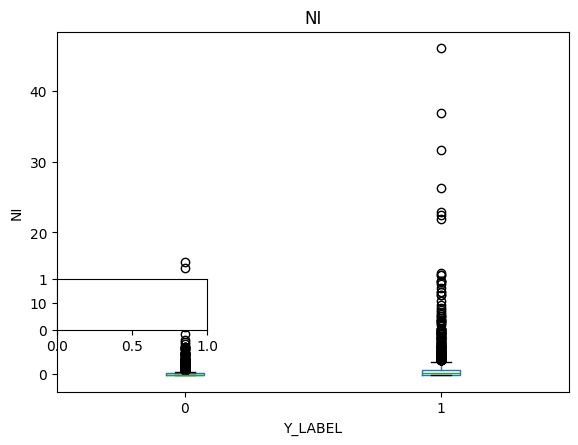

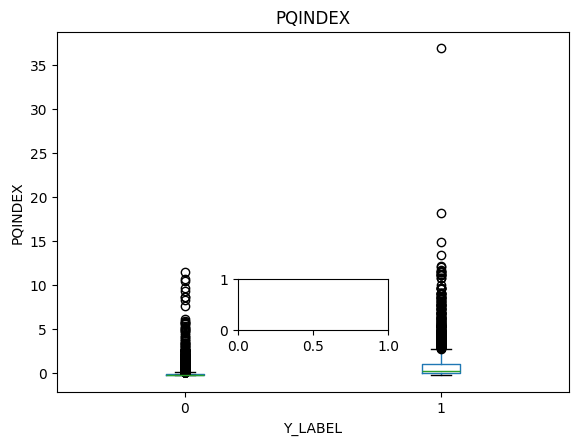

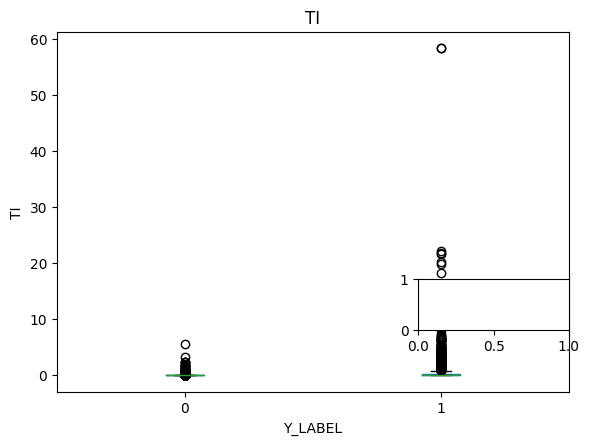

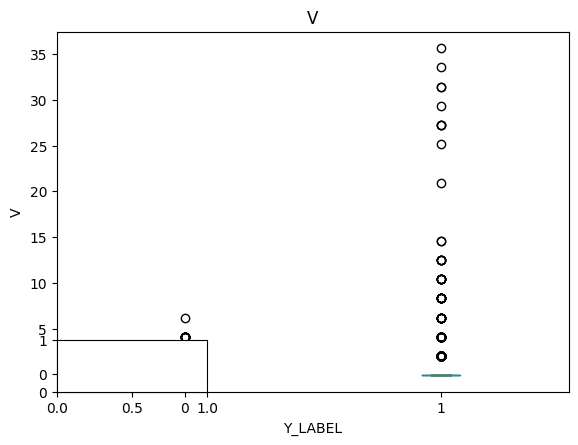

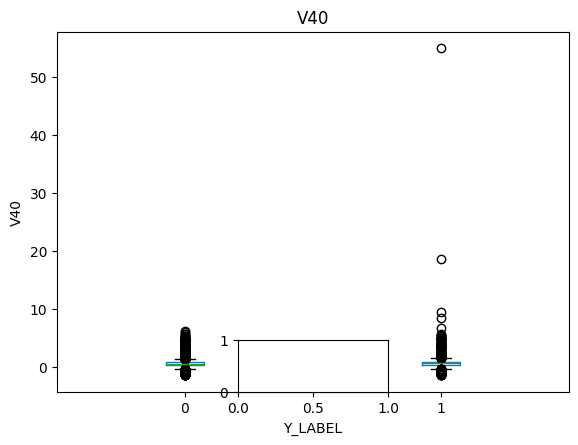

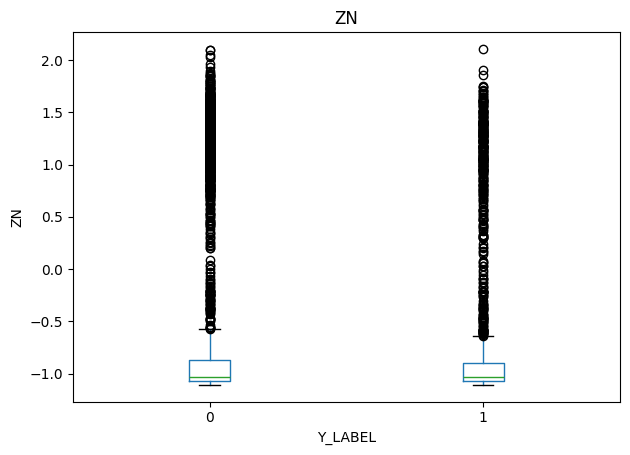

In [72]:
# 변수 리스트 (Y_LABEL, ID, COMPONENT_ARBITRARY 제외)
plot_vars = [col for col in comp3_df.columns if col not in ['ID', 'COMPONENT_ARBITRARY', 'Y_LABEL']]

plt.figure(figsize=(20, 30))
for i, var in enumerate(plot_vars):
  plt.subplot(6, 3, i+1)
  comp3_df.boxplot(column=var, by='Y_LABEL', grid=False)
  plt.title(var)
  plt.suptitle('')
  plt.xlabel('Y_LABEL')
  plt.ylabel(var)
plt.tight_layout()
plt.show()

산점도를 활용하여 분포를 시각적으로 확인해보았다    
파란색: 정상    
빨간색: 비정상    

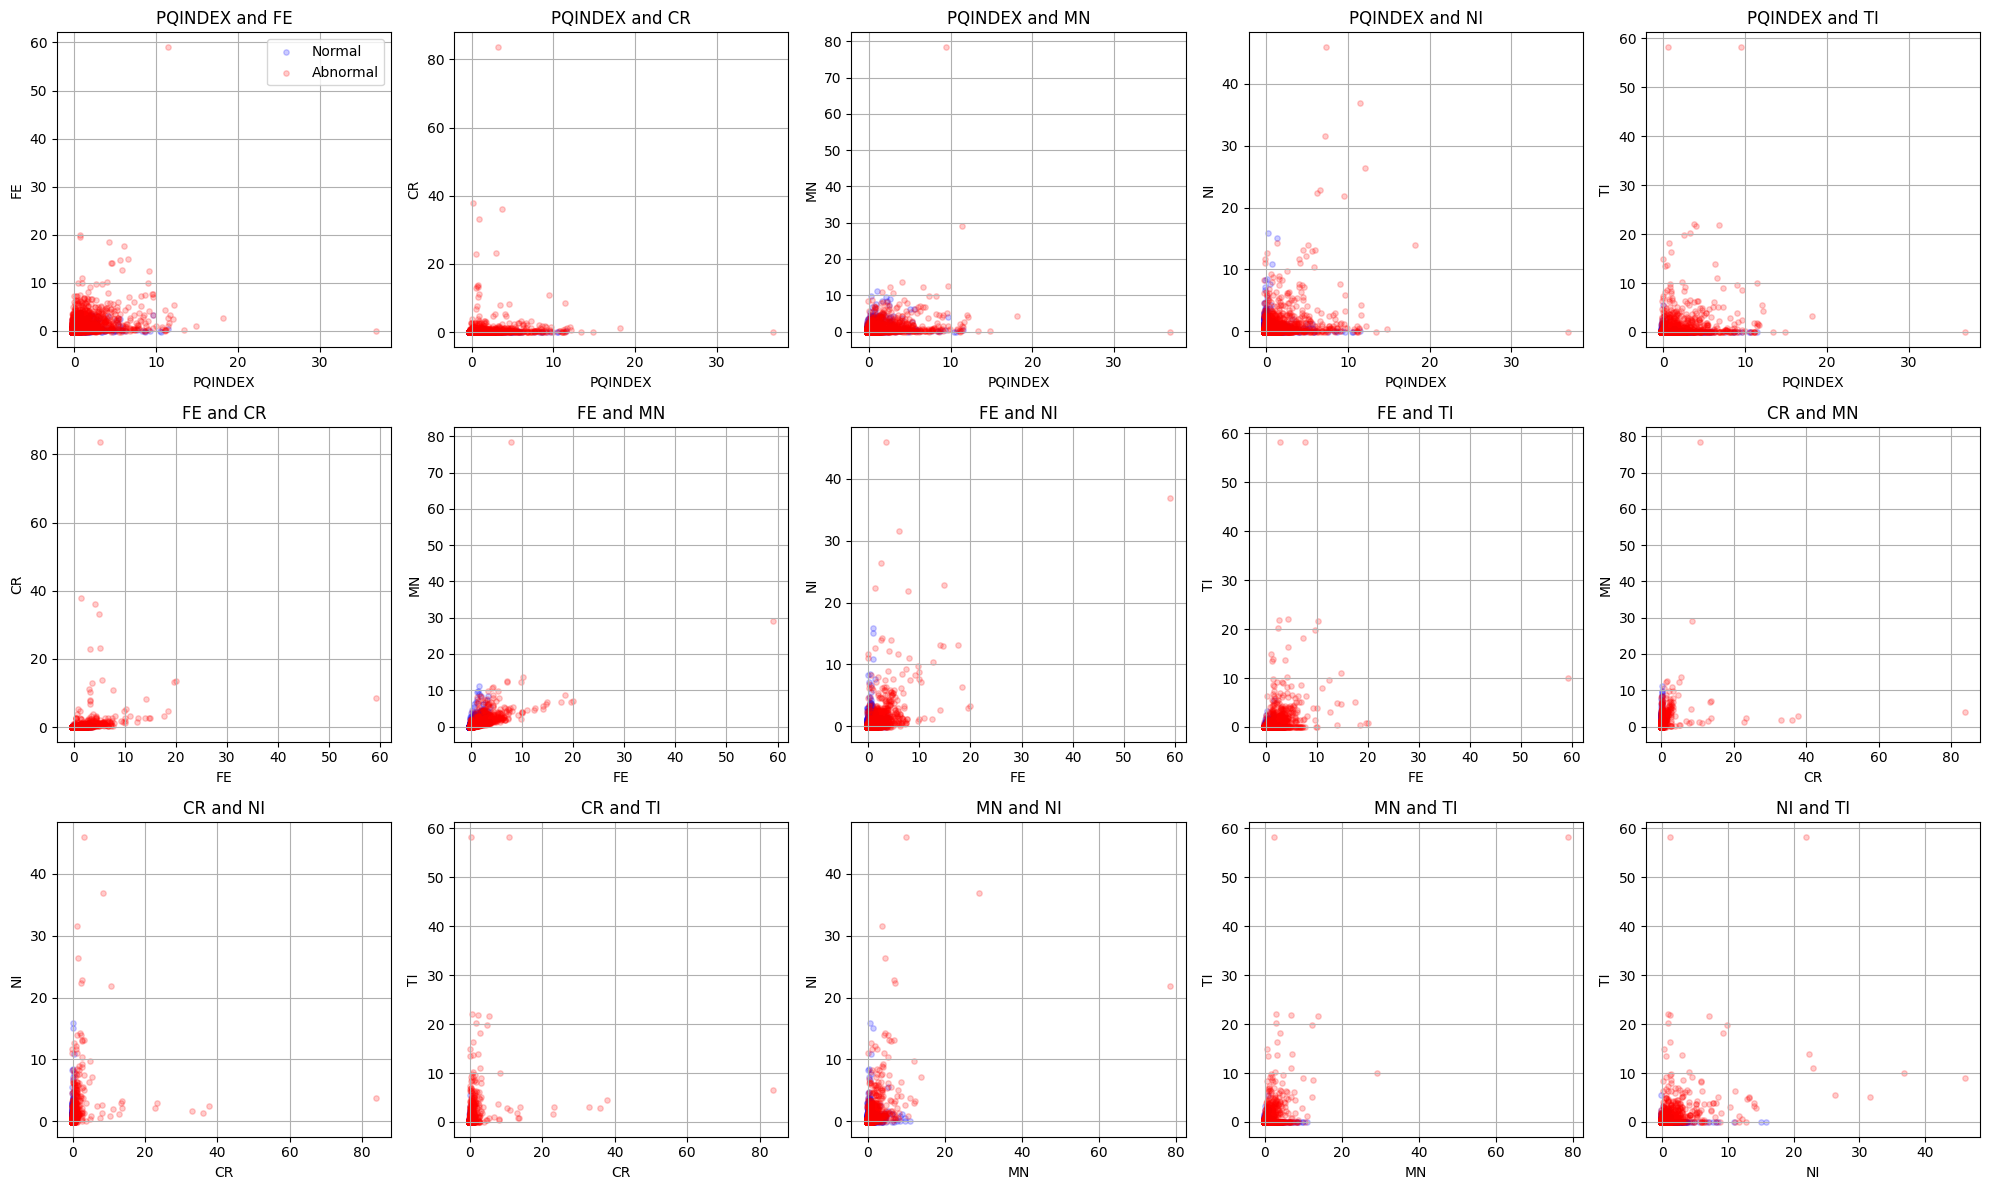

In [73]:
from itertools import combinations

# 산점도에서 색의 투명도를 더 낮추기 위해 alpha 값을 0.2로 조정

# 관련성 높은 변수들 중 2개씩 조합하여 산점도 그리기

important_vars = ['PQINDEX', 'FE', 'CR', 'MN', 'NI', 'TI']

plt.figure(figsize=(20, 12))
for idx, (x_var, y_var) in enumerate(combinations(important_vars, 2)):
  plt.subplot(3, 5, idx+1)
  for y in [0, 1]:
    subset = comp3_df[comp3_df['Y_LABEL'] == y]
    plt.scatter(subset[x_var], subset[y_var], 
          c=colors[y], label=labels[y] if idx == 0 else "", alpha=0.2, s=15)
  plt.xlabel(x_var)
  plt.ylabel(y_var)
  plt.title(f'{x_var} and {y_var}')
  if idx == 0:
    plt.legend()
  plt.grid(True)
plt.tight_layout()
plt.show()

산점도 결과를 보면 비정상 샘플이 더 넓게 분포하고 있는 것을 볼 수 있다

통계적으로 어떤 변수가 종속 변수와 확인하고자 Mann-Whitney U 검정 과정을 진행했다.   

Mann-Whitney U 검정을 사용한 이유   
t-test 검정은 두 그룹의 평균 차이를 검정하는 방법인데,
정규성(각 그룹의 데이터가 정규분포를 따른다는 가정)과 등분산성(두 그룹의 분산이 비슷하다는 가정)이 필요합니다.

하지만 실제 오일 데이터(특히 원소 농도, PQINDEX 등)는 정규분포를 따르지 않는 경우가 많고
이상치(outlier)가 많거나 분포가 치우쳐 있는 경우가 많습니다.
이럴 때 t-test를 사용하면 결과가 왜곡될 수 있기 때문에
비모수 검정인 Mann-Whitney U test(두 그룹의 분포 차이를 비교, 정규성 가정 불필요)를 사용하는 것이 더 적합하다  

In [74]:
# COMPONENT3 데이터에서 독립변수 리스트 (Y_LABEL, ID, COMPONENT_ARBITRARY 제외)
independent_vars = [col for col in comp3_df.columns if col not in ['ID', 'COMPONENT_ARBITRARY', 'Y_LABEL']]

# 결과 저장용
test_results = []

for col in independent_vars:
    # 두 그룹 데이터
    group0 = comp3_0[col]
    group1 = comp3_1[col]
    # 정규성, 등분산성 가정이 어려우므로 Mann-Whitney U test 사용
    stat, p = mannwhitneyu(group0, group1, alternative='two-sided')
    # p-value를 소수점 5자리까지만 표시
    p_rounded = round(p, 5)
    test_results.append({'변수': col, 'Mann-Whitney U 통계량': stat, 'p-value': p_rounded})

# 결과 DataFrame으로 정리
test = pd.DataFrame(test_results)
display(test.sort_values('p-value'))

,변수,Mann-Whitney U 통계량,p-value
8,H2O,4719262.5,0.00000
14,V,4898603.0,0.00000
4,CO,5041572.5,0.00000
5,CR,2238235.5,0.00000
6,CU,4564088.0,0.00000
7,FE,1886591.0,0.00000
15,V40,4855207.0,0.00000
9,MN,2350153.5,0.00000
10,MO,4630501.5,0.00000
11,NI,3286839.5,0.00000


통계적으로 독립 변수와 종속 변수간의 유의미성을 확인하고자  Mann-Whitney U 검정을 진행했다.   
CR, FE, PQINDEX, MN, TI, NI, H2O, V, CO, CU, MO, V40, YEAR, AG 등은 오일의 정상/비정상 여부(Y_LABEL)와 강한 관련성이 있는 반면, ANONYMOUS_1, ZN, ANONYMOUS_2는 정상/비정상 여부와 관련성이 약하거나 없었다.   

관련성이 높은 변수들 중에서도 특히 PQINDEX, FE, CR, MN, NI, TI 이 변수들이 Mann-Whitney U 통계량이 가장 낮은 것을 알 수 있다.   
Mann-Whitney U 값이 작을수록 두 그룹의 분포가 더 많이 겹치지 않고, 차이가 크다는 의미이다.    

 

독립 변수들간의 상관계수를 확인해보았다

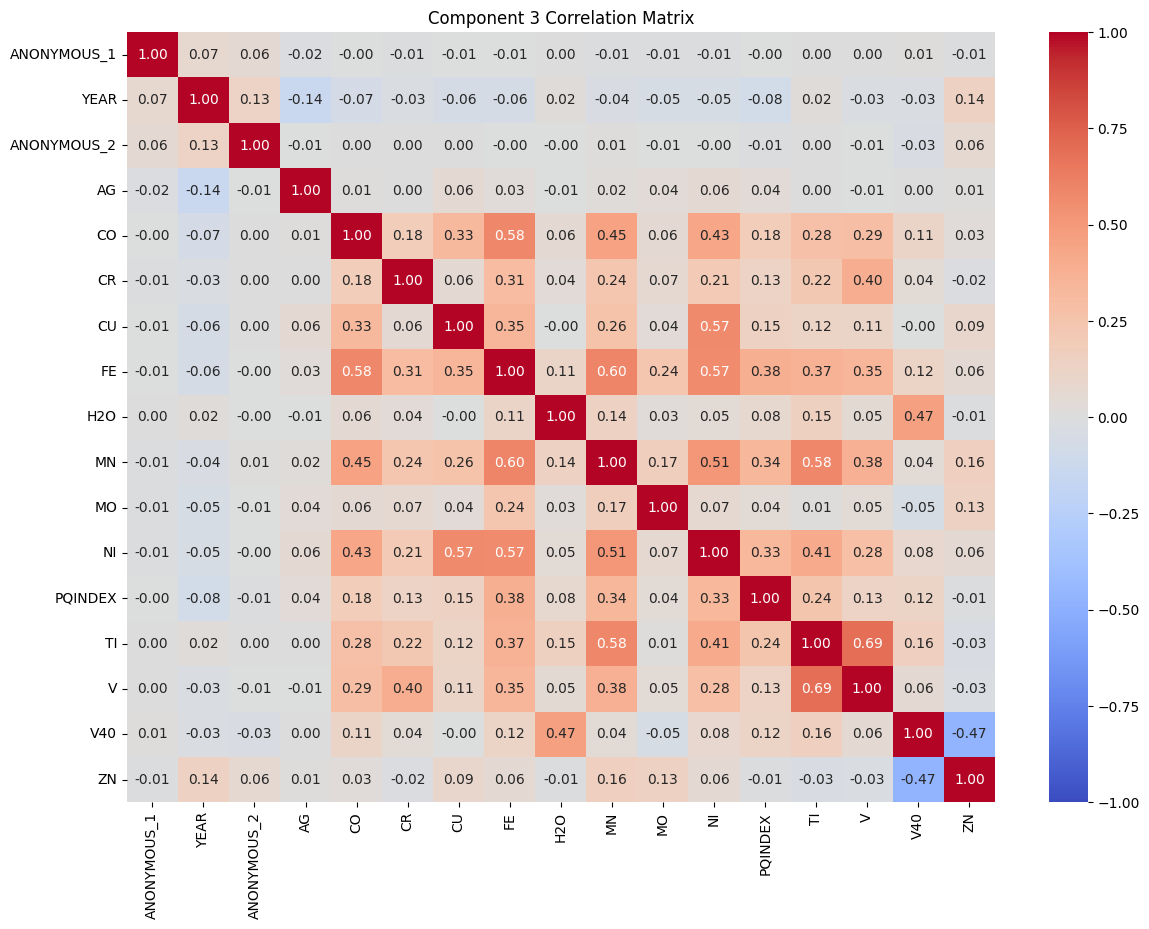

In [75]:
# 변수들간의 상관계수 계산 (수치형 변수만)
corr_matrix = comp3_df[num_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Component 3 Correlation Matrix')
plt.show()

상관계수가 0.7 이상을 넘지 않는 것을 보아 전체적으로 변수들 간의 상관관계가 크지 않다는 것을 볼 수 있었다.    
따라서, 다중공선성 문제는 크지 않을 것으로 판단된다.    

### 모델링 

여러 모델들끼리 성능을 비교하여 가장 성능이 우수한 모델을 발견하고자 한다

In [76]:
# Component 3인 데이터만을 가지고 모델링 진행
comp3_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7050 entries, 0 to 14092
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   7050 non-null   object 
 1   COMPONENT_ARBITRARY  7050 non-null   object 
 2   ANONYMOUS_1          7050 non-null   float64
 3   YEAR                 7050 non-null   float64
 4   ANONYMOUS_2          7050 non-null   float64
 5   AG                   7050 non-null   float64
 6   CO                   7050 non-null   float64
 7   CR                   7050 non-null   float64
 8   CU                   7050 non-null   float64
 9   FE                   7050 non-null   float64
 10  H2O                  7050 non-null   float64
 11  MN                   7050 non-null   float64
 12  MO                   7050 non-null   float64
 13  NI                   7050 non-null   float64
 14  PQINDEX              7050 non-null   float64
 15  TI                   7050 non-null   float

In [79]:
# COMPONENT_ARBITRARY가 'COMPONENT3'인 데이터만 추출
test_df_3 = test_df[test_df['COMPONENT_ARBITRARY'] == 'COMPONENT3']

# 스케일링 적용
test_df_3_scaled = test_df_3.copy()

In [83]:
# 독립변수(X), 종속변수(y) 분리
X = comp3_df[num_cols]
y = comp3_df['Y_LABEL']

# train, test 데이터 분할 (예: 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 분할된 데이터 shape 확인
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (5640, 17) (5640,)
Test shape: (1410, 17) (1410,)


In [ ]:
# 여러 모델 정의
models = {
  'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
  'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
  'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
  'ExtraTrees': ExtraTreesClassifier(n_estimators=100, random_state=42),
  'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
  'XGBoost': XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'),
  'LightGBM': LGBMClassifier(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

  acc = accuracy_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

  results.append({
    'Model': name,
    'Accuracy': acc,
    'F1 Score': f1,
    'ROC AUC': auc
  })

results_df = pd.DataFrame(results)
display(results_df.sort_values('F1 Score', ascending=False))

c:\Users\KimDongyoung\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [19:55:46] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 1715, number of negative: 3925
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000246 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2113
[LightGBM] [Info] Number of data points in the train set: 5640, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.304078 -> initscore=-0.827953
[LightGBM] [Info] Start training from score -0.827953


,Model,Accuracy,F1 Score,ROC AUC
1,RandomForest,0.843972,0.739336,0.919389
3,ExtraTrees,0.844681,0.736462,0.917937
2,GradientBoosting,0.843262,0.734694,0.913214
5,XGBoost,0.839007,0.725514,0.910431
6,LightGBM,0.839007,0.725514,0.915331
4,AdaBoost,0.824113,0.688442,0.882217
0,LogisticRegression,0.814184,0.619186,0.861668


Component3 인 데이터에 한해서 하이퍼파라미터 튜닝없이 모델을 돌렸을 때는 RandomForest가 가장 높은 성능을 보였다

In [92]:
def objective(trial):
  params = {
    'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
    'max_depth': trial.suggest_int('max_depth', 3, 30),
    'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
    'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
    'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
    'random_state': 42,
    'n_jobs': -1
  }
  rf = RandomForestClassifier(**params)
  score = cross_val_score(rf, X_train, y_train, scoring='f1', cv=5, n_jobs=-1)
  return score.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best parameters:", study.best_params)
print("Best F1 score (CV):", study.best_value)

# 최적 모델로 테스트셋 평가
best_rf = RandomForestClassifier(**study.best_params, random_state=42, n_jobs=-1)
best_rf.fit(X_train, y_train)
y_pred_best = best_rf.predict(X_test)
y_proba_best = best_rf.predict_proba(X_test)[:, 1]

acc_best = accuracy_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
auc_best = roc_auc_score(y_test, y_proba_best)

print(f"Test Accuracy: {acc_best:.4f}")
print(f"Test F1 Score: {f1_best:.4f}")
print(f"Test ROC AUC: {auc_best:.4f}")

[I 2025-06-04 20:04:43,539] A new study created in memory with name: no-name-2cdefef1-9474-4419-af4a-24beb1c77885


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-06-04 20:04:46,087] Trial 0 finished with value: 0.7376221849402758 and parameters: {'n_estimators': 300, 'max_depth': 14, 'min_samples_split': 18, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.7376221849402758.
[I 2025-06-04 20:04:47,998] Trial 1 finished with value: 0.6948629884456105 and parameters: {'n_estimators': 400, 'max_depth': 6, 'min_samples_split': 14, 'min_samples_leaf': 10, 'max_features': 'log2'}. Best is trial 0 with value: 0.7376221849402758.
[I 2025-06-04 20:04:48,864] Trial 2 finished with value: 0.7376385862417839 and parameters: {'n_estimators': 100, 'max_depth': 13, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 2 with value: 0.7376385862417839.
[I 2025-06-04 20:04:53,357] Trial 3 finished with value: 0.7371165799033637 and parameters: {'n_estimators': 450, 'max_depth': 20, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.737638586241

Optuna 방식을 적용해서 하이퍼파라미터 튜닝을 적용했을 때 test data에 대한 F1 score가 0.7503로 증가한 것을 알 수 있다

In [ ]:
# best_params 저장
with open('best_rf_params.pkl', 'wb') as f:
  pickle.dump(study.best_params, f)

# 나중에 불러와서 바로 사용
with open('best_rf_params.pkl', 'rb') as f:
  loaded_params = pickle.load(f)

# 모델에 적용
# rf = RandomForestClassifier(**loaded_params, random_state=42, n_jobs=-1)
# rf.fit(X_train, y_train)

'rf.fit(X_train, y_train)'

In [96]:
# Optuna를 활용해 LightGBM, XGBoost, ExtraTrees 등 다른 모델도 하이퍼파라미터 튜닝 및 성능 비교

# LightGBM 모델 튜닝 함수
def lgbm_objective(trial):
  params = {
    'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
    'max_depth': trial.suggest_int('max_depth', 3, 30),
    'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
    'num_leaves': trial.suggest_int('num_leaves', 20, 100),
    'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
    'subsample': trial.suggest_float('subsample', 0.5, 1.0),
    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
    'random_state': 42,
    'n_jobs': -1
  }
  model = LGBMClassifier(**params)
  score = cross_val_score(model, X_train, y_train, scoring='f1', cv=5, n_jobs=-1)
  return score.mean()

In [97]:
# XGBoost 모델 튜닝 함수
def xgb_objective(trial):
  params = {
    'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
    'max_depth': trial.suggest_int('max_depth', 3, 30),
    'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
    'subsample': trial.suggest_float('subsample', 0.5, 1.0),
    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
    'gamma': trial.suggest_float('gamma', 0, 5),
    'random_state': 42,
    'use_label_encoder': False,
    'eval_metric': 'logloss',
    'n_jobs': -1
  }
  model = XGBClassifier(**params)
  score = cross_val_score(model, X_train, y_train, scoring='f1', cv=5, n_jobs=-1)
  return score.mean()

In [98]:
# ExtraTrees 모델 튜닝 함수
def extratrees_objective(trial):
  params = {
    'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
    'max_depth': trial.suggest_int('max_depth', 3, 30),
    'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
    'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
    'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
    'random_state': 42,
    'n_jobs': -1
  }
  model = ExtraTreesClassifier(**params)
  score = cross_val_score(model, X_train, y_train, scoring='f1', cv=5, n_jobs=-1)
  return score.mean()

In [99]:
# 각 모델별 Optuna 튜닝 및 결과 저장
studies = {}
best_models = {}
for model_name, objective_func, model_cls in [
  ('LightGBM', lgbm_objective, LGBMClassifier),
  ('XGBoost', xgb_objective, XGBClassifier),
  ('ExtraTrees', extratrees_objective, ExtraTreesClassifier)
]:
  study = optuna.create_study(direction='maximize')
  study.optimize(objective_func, n_trials=30, show_progress_bar=True)
  print(f"{model_name} Best params:", study.best_params)
  print(f"{model_name} Best F1 score (CV):", study.best_value)
  # 최적 모델로 테스트셋 평가
  best_model = model_cls(**study.best_params, random_state=42, n_jobs=-1)
  best_model.fit(X_train, y_train)
  y_pred = best_model.predict(X_test)
  y_proba = best_model.predict_proba(X_test)[:, 1]
  acc = accuracy_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  auc = roc_auc_score(y_test, y_proba)
  print(f"{model_name} Test Accuracy: {acc:.4f}")
  print(f"{model_name} Test F1 Score: {f1:.4f}")
  print(f"{model_name} Test ROC AUC: {auc:.4f}")
  studies[model_name] = study
  best_models[model_name] = best_model

[I 2025-06-04 20:14:52,144] A new study created in memory with name: no-name-c2ab345c-eb19-49b1-8d9a-557f3fd039f0


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-06-04 20:14:58,708] Trial 0 finished with value: 0.7228859639371679 and parameters: {'n_estimators': 300, 'max_depth': 28, 'learning_rate': 0.05504230869264787, 'num_leaves': 91, 'min_child_samples': 24, 'subsample': 0.753638184531666, 'colsample_bytree': 0.5015761331936488}. Best is trial 0 with value: 0.7228859639371679.
[I 2025-06-04 20:15:03,595] Trial 1 finished with value: 0.72460166868625 and parameters: {'n_estimators': 300, 'max_depth': 17, 'learning_rate': 0.11783062958281919, 'num_leaves': 72, 'min_child_samples': 18, 'subsample': 0.9029987482730533, 'colsample_bytree': 0.9754147689372161}. Best is trial 1 with value: 0.72460166868625.
[I 2025-06-04 20:15:08,004] Trial 2 finished with value: 0.7248317948895834 and parameters: {'n_estimators': 250, 'max_depth': 21, 'learning_rate': 0.04865071641244028, 'num_leaves': 88, 'min_child_samples': 34, 'subsample': 0.6512537290233655, 'colsample_bytree': 0.5345150092545363}. Best is trial 2 with value: 0.7248317948895834.
[I 

[I 2025-06-04 20:15:53,018] A new study created in memory with name: no-name-4ec851a7-165e-4a1d-9e13-aa062dfad506


LightGBM Test Accuracy: 0.8312
LightGBM Test F1 Score: 0.7160
LightGBM Test ROC AUC: 0.9119


...

[I 2025-06-04 20:15:53,588] Trial 0 finished with value: 0.7321722877242902 and parameters: {'n_estimators': 400, 'max_depth': 30, 'learning_rate': 0.026989421574874446, 'subsample': 0.8214606369677399, 'colsample_bytree': 0.8183485926832519, 'gamma': 4.6019360567637015}. Best is trial 0 with value: 0.7321722877242902.
[I 2025-06-04 20:15:53,869] Trial 1 finished with value: 0.7307882848558979 and parameters: {'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.14455128909657297, 'subsample': 0.9076994378964605, 'colsample_bytree': 0.7574199894211875, 'gamma': 3.3091241274409624}. Best is trial 0 with value: 0.7321722877242902.
[I 2025-06-04 20:15:54,760] Trial 2 finished with value: 0.7401821219016445 and parameters: {'n_estimators': 450, 'max_depth': 21, 'learning_rate': 0.011252669519792636, 'subsample': 0.7328779108775996, 'colsample_bytree': 0.897551558145552, 'gamma': 3.4162654677292776}. Best is trial 2 with value: 0.7401821219016445.
[I 2025-06-04 20:15:55,140] Trial 3 fin

[I 2025-06-04 20:16:07,777] A new study created in memory with name: no-name-e78c7707-fabf-4f55-98ea-8e09270ae8db


XGBoost Test Accuracy: 0.8383
XGBoost Test F1 Score: 0.7279
XGBoost Test ROC AUC: 0.9181


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-06-04 20:16:08,623] Trial 0 finished with value: 0.4285344492505372 and parameters: {'n_estimators': 300, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 0 with value: 0.4285344492505372.
[I 2025-06-04 20:16:09,089] Trial 1 finished with value: 0.32664864679551786 and parameters: {'n_estimators': 150, 'max_depth': 5, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.4285344492505372.
[I 2025-06-04 20:16:09,506] Trial 2 finished with value: 0.5984767677974199 and parameters: {'n_estimators': 100, 'max_depth': 21, 'min_samples_split': 7, 'min_samples_leaf': 8, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.5984767677974199.
[I 2025-06-04 20:16:10,573] Trial 3 finished with value: 0.6093755546526609 and parameters: {'n_estimators': 400, 'max_depth': 20, 'min_samples_split': 12, 'min_samples_leaf': 7, 'max_features': 'log2'}. Best is trial 3 with value: 0.6093755546526

XGBoost: 0.7279, ExtraTrees: 0.7095, LightGBM: 0.7160   
RandomForest이 Component3 에 한정해서 가장 높은 성능을 보였다   

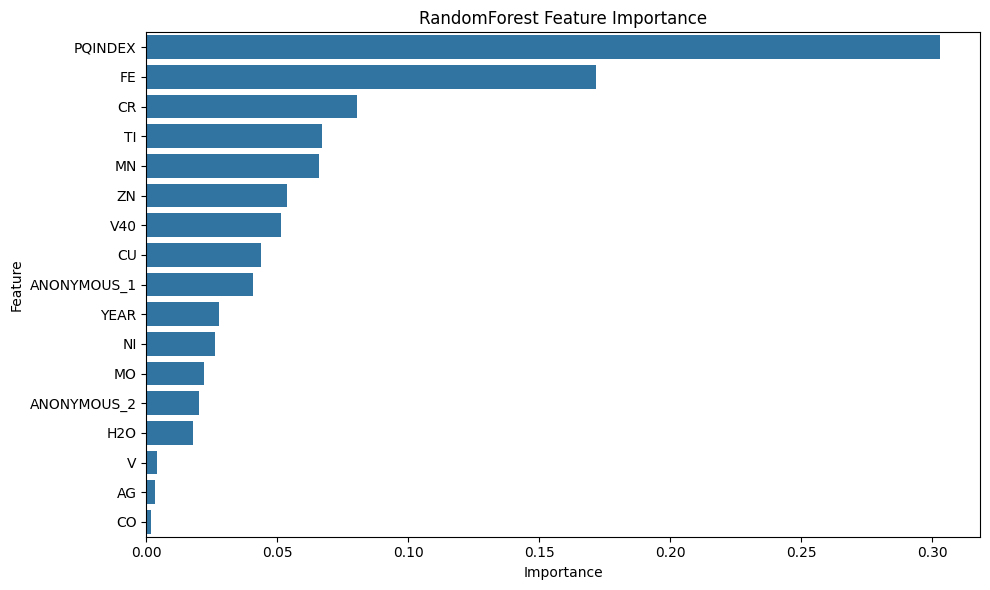

In [100]:
# 예시: RandomForestClassifier의 feature importance 시각화

importances = best_rf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('RandomForest Feature Importance')
plt.tight_layout()
plt.show()

Feature importance는 트리 기반 모델에서 각 변수가 예측 시 얼마나 중요한 역할을 했는지를 정량적으로 나타내는 지표이다.   
RandomForest 에서는 PQINDEX, FE, CR, TI, MN 변수의 영향력이 높았다.   
예상대로 이 5개의 변수는 통계 검정에서 종속 변수와 가장 높은 관계를 보인 변수이다.    